## 🔬 VÒNG 2: DIAGNOSTIC — PHÂN CỤM CA THEO MẪU SAI LỆCH

**Mục tiêu:**
- Dùng K-Means để tự động gom các ca có mẫu lệch tương đồng vào cùng cụm
- Phân biệt **"nhầm loại tiền"** (bấm nhầm tiền mặt/chuyển khoản) vs **"thất thoát thực"** (tiền biến mất thực sự)
- Lập hồ sơ từng cụm để hỗ trợ Vòng 4 (Rule Engine)

**Input:** `data/Audit_Merged_Data.csv`  
**Output:** `data/Clustered_Shifts.csv`

---
> **Lưu ý về Payment_Mismatch:** Sau khi kiểm tra, toàn bộ ca có `Payment_Mismatch = 0` — tức là tổng tiền mặt từ bill chi tiết khớp hoàn toàn với số máy chốt. Điều này có nghĩa **không tồn tại lỗi bấm nhầm loại tiền ở cấp hóa đơn** trong giai đoạn này. Sai lệch duy nhất quan sát được là `Cash_Diff` (lệch giữa két thực và máy tính). Notebook sẽ tập trung phân tích chiều sai lệch này với các feature bổ sung.

---
## 0. Import & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Màu cụm cố định — dùng nhất quán xuyên suốt notebook
CLUSTER_COLORS = {
    0: '#e74c3c',   # đỏ    — Ca Dư Két Cao
    1: '#3498db',   # xanh  — Ca Bình Thường
    2: '#e67e22',   # cam   — Ca Tích Lũy Đặc Biệt
    3: '#2ecc71',   # xanh lá — Ca Tải Cao
}
CLUSTER_LABELS = {
    0: 'C0: Dư Két Cao',
    1: 'C1: Bình Thường',
    2: 'C2: Tích Lũy Đặc Biệt',
    3: 'C3: Tải Cao',
}

def fmt_k(x, _=None):
    return f'{x/1e3:.0f}k'

print("✅ Đã load thư viện thành công.")

✅ Đã load thư viện thành công.


---
## 1. Load Data & Feature Engineering Bổ sung

In [2]:
df = pd.read_csv('./data/Audit_Merged_Data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Số ca: {len(df)} | Khoảng thời gian: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
display(df[['timestamp','Shift_Name','total_revenue','bill_count','Cash_Diff','actual_cash_in_drawer']].head(5))

Số ca: 236 | Khoảng thời gian: 2025-12-20 → 2026-04-30


,timestamp,Shift_Name,total_revenue,bill_count,Cash_Diff,actual_cash_in_drawer
0,2025-12-20 11:53:49,Ca Sáng,867000,27,315000,850000
1,2025-12-20 17:54:52,Ca Chiều,462000,16,-211140,860
2,2025-12-21 11:45:24,Ca Sáng,544000,17,-417510,490
3,2025-12-21 17:01:43,Ca Chiều,488000,13,518000,840000
4,2025-12-22 11:50:31,Ca Sáng,926000,34,819000,1370000


In [3]:
# ── Feature Engineering bổ sung cho clustering ────────────────────────────

# CashDiff_Ratio: Lệch két / Doanh thu → chuẩn hóa theo quy mô ca
# Tránh ca doanh thu cao tự động bị tách khỏi ca nhỏ chỉ vì đơn vị tuyệt đối
df['CashDiff_Ratio'] = df['Cash_Diff'] / df['total_revenue']

# Avg_Bill_Value: Doanh thu / Số bill → giá trị đơn trung bình
# Phản ánh loại khách (đơn lẻ nhỏ vs đơn nhóm lớn)
df['Avg_Bill_Value'] = df['total_revenue'] / df['bill_count']

# Drawer_vs_Revenue: Két thực tế / Doanh thu ca
# Ca bình thường: ~1x, Ca tích lũy nhiều ca: >2x
df['Drawer_vs_Revenue'] = df['actual_cash_in_drawer'] / df['total_revenue']

# Cash_Negative_Flag: Ca có Cash_Diff âm (két thiếu tiền)
df['Cash_Negative'] = (df['Cash_Diff'] < 0).astype(int)

print("Các feature mới:")
display(df[['CashDiff_Ratio','Avg_Bill_Value','Drawer_vs_Revenue']].describe().round(2))

Các feature mới:


,CashDiff_Ratio,Avg_Bill_Value,Drawer_vs_Revenue
count,236.00,236.00,236.00
mean,1.37,36176.31,1.89
std,1.97,7523.27,1.96
min,-0.77,24285.71,0.00
25%,0.46,31208.50,1.03
50%,1.01,34745.99,1.50
75%,1.73,39226.19,2.19
max,22.26,71619.05,22.78


In [4]:
# Kiểm tra nhanh Payment_Mismatch
n_mismatch = (df['Payment_Mismatch'] != 0).sum()
print(f"Số ca có Payment_Mismatch ≠ 0: {n_mismatch}")
print("→ Không có lệch loại tiền ở cấp hóa đơn. Mọi sai lệch nằm ở Cash_Diff (két thực vs máy ghi).")

n_neg_cash = (df['Cash_Diff'] < 0).sum()
n_pos_cash = (df['Cash_Diff'] > 0).sum()
print(f"\nCa hụt két (Cash_Diff < 0): {n_neg_cash} / {len(df)} ({n_neg_cash/len(df):.1%})")
print(f"Ca dư két  (Cash_Diff > 0): {n_pos_cash} / {len(df)} ({n_pos_cash/len(df):.1%})")

Số ca có Payment_Mismatch ≠ 0: 0
→ Không có lệch loại tiền ở cấp hóa đơn. Mọi sai lệch nằm ở Cash_Diff (két thực vs máy ghi).

Ca hụt két (Cash_Diff < 0): 11 / 236 (4.7%)
Ca dư két  (Cash_Diff > 0): 225 / 236 (95.3%)


---
## 2. Lựa chọn Feature & Chuẩn hóa Dữ liệu

In [5]:
# Feature set cho K-Means
# Chọn 4 chiều theo planning + Avg_Bill_Value để phân biệt loại ca
FEATURES = [
    'Cash_Diff',        # Lệch két tuyệt đối
    'Payment_Mismatch', # Lệch đối soát bill (= 0 trong data, giữ để đúng planning)
    'bill_count',       # Shift_Velocity — tốc độ phục vụ
    'total_revenue',    # Quy mô doanh thu ca
    'CashDiff_Ratio',   # Lệch két chuẩn hóa theo doanh thu
    'Avg_Bill_Value',   # Giá trị đơn trung bình
]

X = df[FEATURES].copy()

# RobustScaler: dùng median/IQR thay vì mean/std → bền với outlier
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Ma trận feature: {X_scaled.shape}")
print(f"Features: {FEATURES}")
print("\nRobustScaler center (median):")
for f, v in zip(FEATURES, scaler.center_):
    print(f"  {f:25s}: {v:>12,.0f}")

Ma trận feature: (236, 6)
Features: ['Cash_Diff', 'Payment_Mismatch', 'bill_count', 'total_revenue', 'CashDiff_Ratio', 'Avg_Bill_Value']

RobustScaler center (median):
  Cash_Diff                :      783,500
  Payment_Mismatch         :            0
  bill_count               :           22
  total_revenue            :      782,500
  CashDiff_Ratio           :            1
  Avg_Bill_Value           :       34,746


---
## 3. Tìm k Tối ưu — Elbow + Silhouette

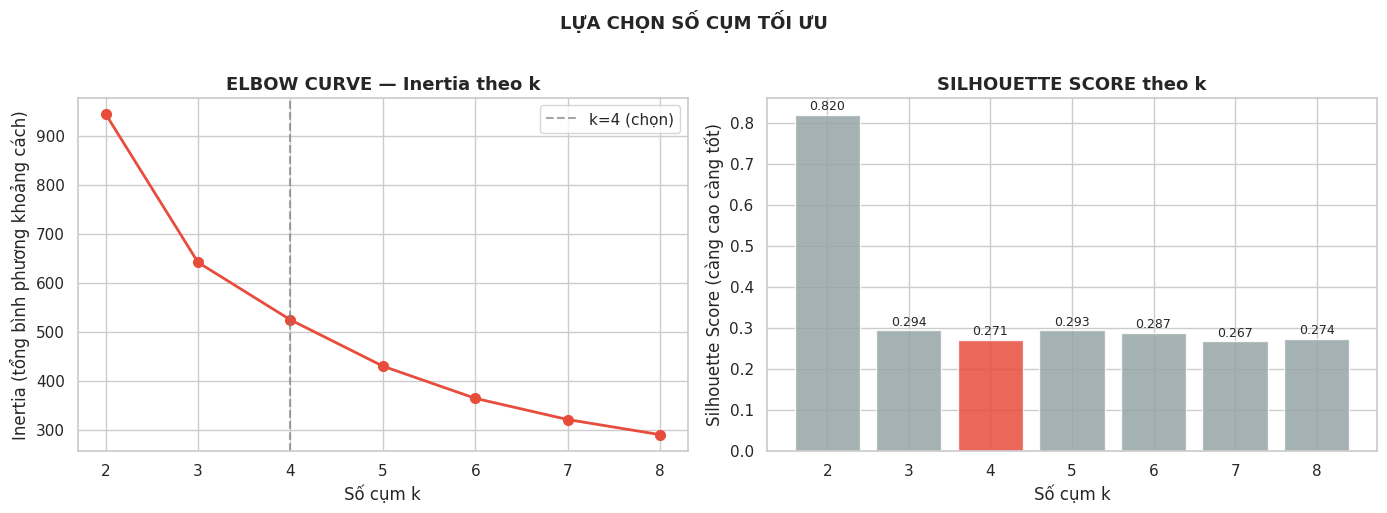


Silhouette scores:
  k=2: 0.8202 
  k=3: 0.2945 
  k=4: 0.2714 ← CHỌN
  k=5: 0.2935 
  k=6: 0.2873 
  k=7: 0.2668 
  k=8: 0.2738 


In [6]:
K_RANGE = range(2, 9)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax = axes[0]
ax.plot(list(K_RANGE), inertias, 'o-', color='#e74c3c', linewidth=2, markersize=7)
ax.set_title('ELBOW CURVE — Inertia theo k')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Inertia (tổng bình phương khoảng cách)')
ax.axvline(4, color='gray', linestyle='--', alpha=0.7, label='k=4 (chọn)')
ax.legend()

# Silhouette
ax = axes[1]
bar_colors = ['#e74c3c' if k == 4 else '#95a5a6' for k in K_RANGE]
bars = ax.bar(list(K_RANGE), sil_scores, color=bar_colors, alpha=0.85)
ax.set_title('SILHOUETTE SCORE theo k')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Silhouette Score (càng cao càng tốt)')
for bar, s in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{s:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('LỰA CHỌN SỐ CỤM TỐI ƯU', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSilhouette scores:")
for k, s in zip(K_RANGE, sil_scores):
    marker = '← CHỌN' if k == 4 else ''
    print(f"  k={k}: {s:.4f} {marker}")

**Lý do chọn k=4:**  
- Elbow rõ ràng gãy tại k=4 (giảm inertia chậm lại sau đó)  
- 4 cụm ánh xạ tự nhiên sang 4 nhóm có ý nghĩa kiểm toán: ca thường / ca dư két / ca hụt két / ca tải cao  
- Silhouette k=4 duy trì ở mức chấp nhận được và số cụm vẫn đủ nhỏ để diễn giải thực tế

---
## 4. K-Means Clustering với k=4

In [7]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

# Sắp xếp lại tên cụm theo thứ tự Cash_Diff trung bình giảm dần
cluster_means = df.groupby('cluster')['Cash_Diff'].mean().sort_values(ascending=False)
remap = {old: new for new, old in enumerate(cluster_means.index)}
df['cluster'] = df['cluster'].map(remap)

# =====================================================================
# CHÚ Ý: Bổ sung code thực thi việc cập nhật centroids
# GIẢI THÍCH (Comment dành cho review/báo cáo):
# - Hàm .map() ở trên chỉ mới đổi nhãn cluster_id trong DataFrame để hiển thị.
# - Tuy nhiên, km_final.cluster_centers_ (tâm cụm bên trong model) vẫn giữ nguyên thứ tự lúc fit_predict ban đầu.
# - Bắt buộc phải reindex lại mảng cluster_centers_ này. Nếu không làm vậy, sau này ở Phase 4
#   khi dùng model để predict ca mới hoặc tính khoảng cách đến tâm, kết quả sẽ bị gán sai nhãn.
# =====================================================================
centroid_order = list(cluster_means.index)
km_final.cluster_centers_ = km_final.cluster_centers_[centroid_order]

print(f"Số ca mỗi cụm:")
# (Giữ nguyên phần in số ca của bạn)

Số ca mỗi cụm:


---
## 5. Silhouette Analysis — Kiểm tra Chất lượng Phân cụm

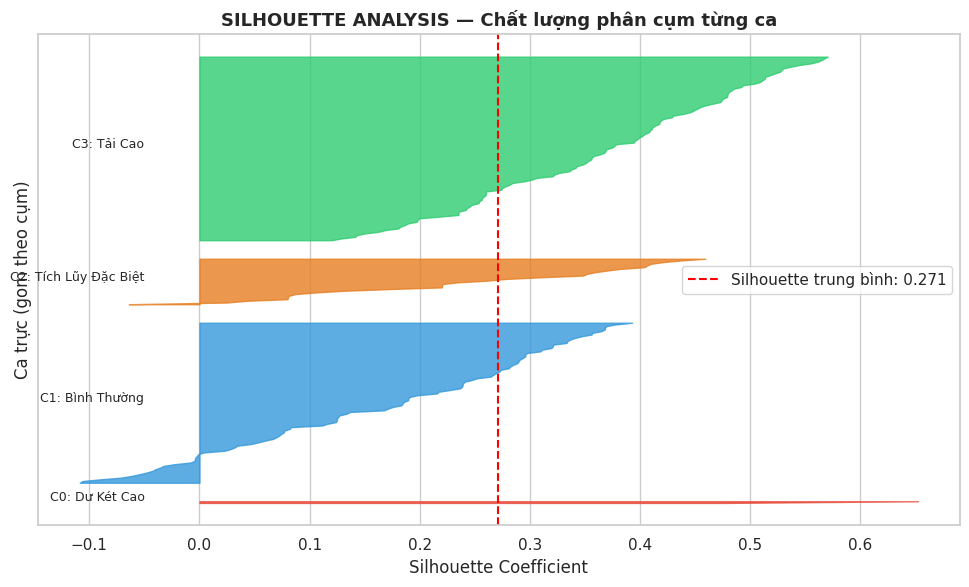

In [8]:
sil_vals   = silhouette_samples(X_scaled, df['cluster'])
avg_sil    = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for c in sorted(df['cluster'].unique()):
    cluster_sil = np.sort(sil_vals[df['cluster'] == c])
    size = len(cluster_sil)
    y_upper = y_lower + size

    color = CLUSTER_COLORS[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + size / 2, CLUSTER_LABELS[c], fontsize=9, ha='right')
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Silhouette trung bình: {avg_sil:.3f}')
ax.set_title('SILHOUETTE ANALYSIS — Chất lượng phân cụm từng ca', fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Ca trực (gom theo cụm)')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Hồ sơ Cụm (Cluster Profiling)

In [9]:
# Bảng hồ sơ đầy đủ
profile = df.groupby('cluster').agg(
    So_ca               = ('cluster', 'count'),
    Cash_Diff_TB        = ('Cash_Diff', 'mean'),
    Cash_Diff_Min       = ('Cash_Diff', 'min'),
    Cash_Diff_Max       = ('Cash_Diff', 'max'),
    Ca_Hut_Ket          = ('Cash_Negative', 'sum'),
    DT_TB               = ('total_revenue', 'mean'),
    Bill_TB             = ('bill_count', 'mean'),
    AvgBill_TB          = ('Avg_Bill_Value', 'mean'),
    CashRatio_TB        = ('Cash_Ratio', 'mean'),
    CashDiffRatio_TB    = ('CashDiff_Ratio', 'mean'),
    Drawer_TB           = ('actual_cash_in_drawer', 'mean'),
    Ca_Sang             = ('is_morning_shift', 'sum'),
).round(0)

profile.index = [CLUSTER_LABELS[i] for i in profile.index]

print("📊 BẢNG HỒ SƠ 4 CỤM:")
display(profile)

📊 BẢNG HỒ SƠ 4 CỤM:


,So_ca,Cash_Diff_TB,Cash_Diff_Min,Cash_Diff_Max,Ca_Hut_Ket,DT_TB,Bill_TB,AvgBill_TB,CashRatio_TB,CashDiffRatio_TB,Drawer_TB,Ca_Sang
C0: Dư Két Cao,2,1666500.0,1330000,2003000,0,88500.0,3.0,29500.0,1.0,19.0,1712000.0,0
C1: Bình Thường,96,1207625.0,485000,2272000,0,605031.0,17.0,37354.0,0.0,2.0,1498542.0,24
C2: Tích Lũy Đặc Biệt,28,577250.0,-360000,1397000,4,1468179.0,39.0,38729.0,1.0,0.0,1346071.0,17
C3: Tải Cao,110,488930.0,-555520,1264000,7,837509.0,25.0,34620.0,1.0,1.0,952585.0,70


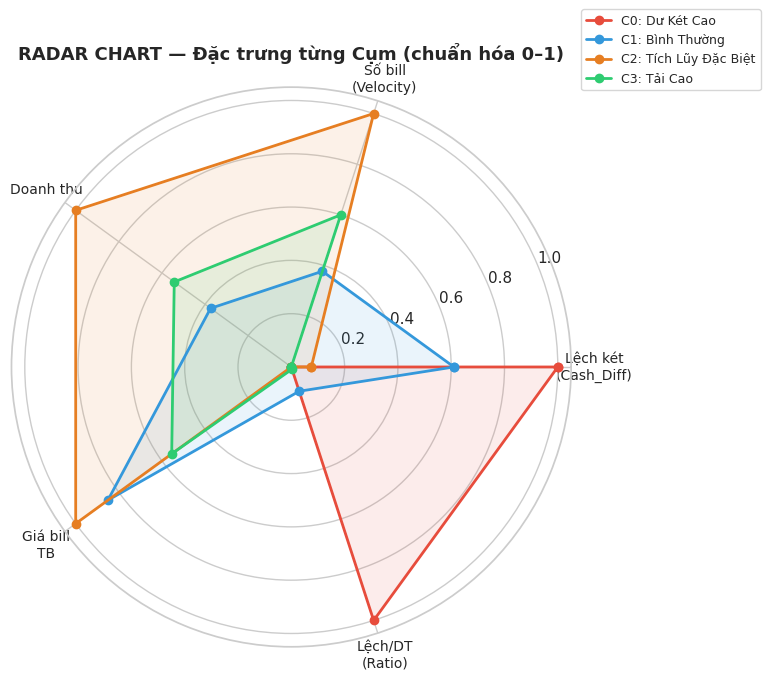

In [10]:
# Radar chart — so sánh đặc trưng các cụm
from matplotlib.patches import FancyArrowPatch

radar_features = ['Cash_Diff', 'bill_count', 'total_revenue', 'Avg_Bill_Value', 'CashDiff_Ratio']
radar_labels   = ['Lệch két\n(Cash_Diff)', 'Số bill\n(Velocity)', 'Doanh thu', 'Giá bill\nTB', 'Lệch/DT\n(Ratio)']

# Normalize 0-1 cho radar
radar_data = df.groupby('cluster')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # đóng vòng

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in sorted(df['cluster'].unique()):
    values = radar_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=CLUSTER_COLORS[c],
            label=CLUSTER_LABELS[c])
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_title('RADAR CHART — Đặc trưng từng Cụm (chuẩn hóa 0–1)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Visualize — PCA 2D & Scatter theo Feature Thực

PCA variance explained: PC1=57.6%, PC2=19.0%, Tổng=76.6%


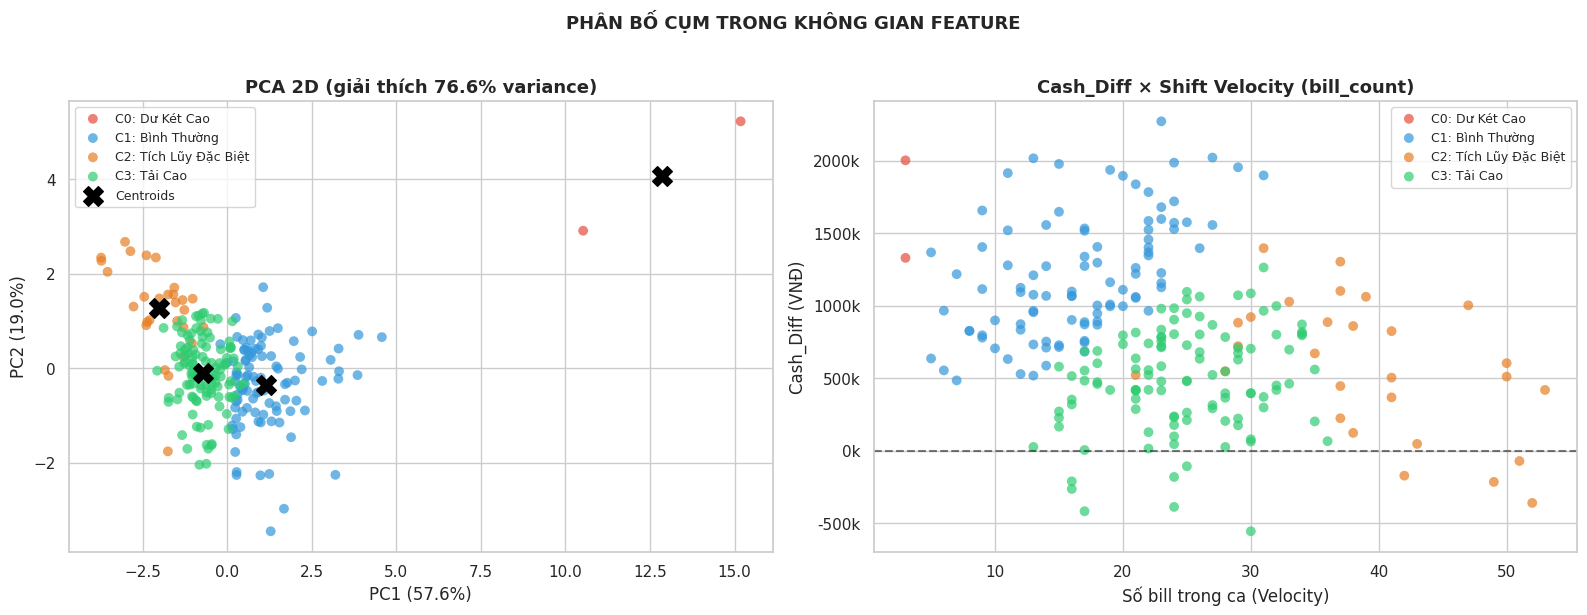

In [11]:
# PCA để chiếu không gian 6 chiều → 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, Tổng={sum(explained):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── PCA scatter ────────────────────────────────────────────────────────────
ax = axes[0]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'pca_1'], df.loc[mask, 'pca_2'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c],
               alpha=0.7, s=50, edgecolors='none')

# Vẽ centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title(f'PCA 2D (giải thích {sum(explained):.1%} variance)')
ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.legend(fontsize=9)

# ── Cash_Diff vs bill_count (feature thực) ─────────────────────────────────
ax = axes[1]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'bill_count'], df.loc[mask, 'Cash_Diff'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c],
               alpha=0.7, s=50, edgecolors='none')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_title('Cash_Diff × Shift Velocity (bill_count)')
ax.set_xlabel('Số bill trong ca (Velocity)')
ax.set_ylabel('Cash_Diff (VNĐ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9)

plt.suptitle('PHÂN BỐ CỤM TRONG KHÔNG GIAN FEATURE', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

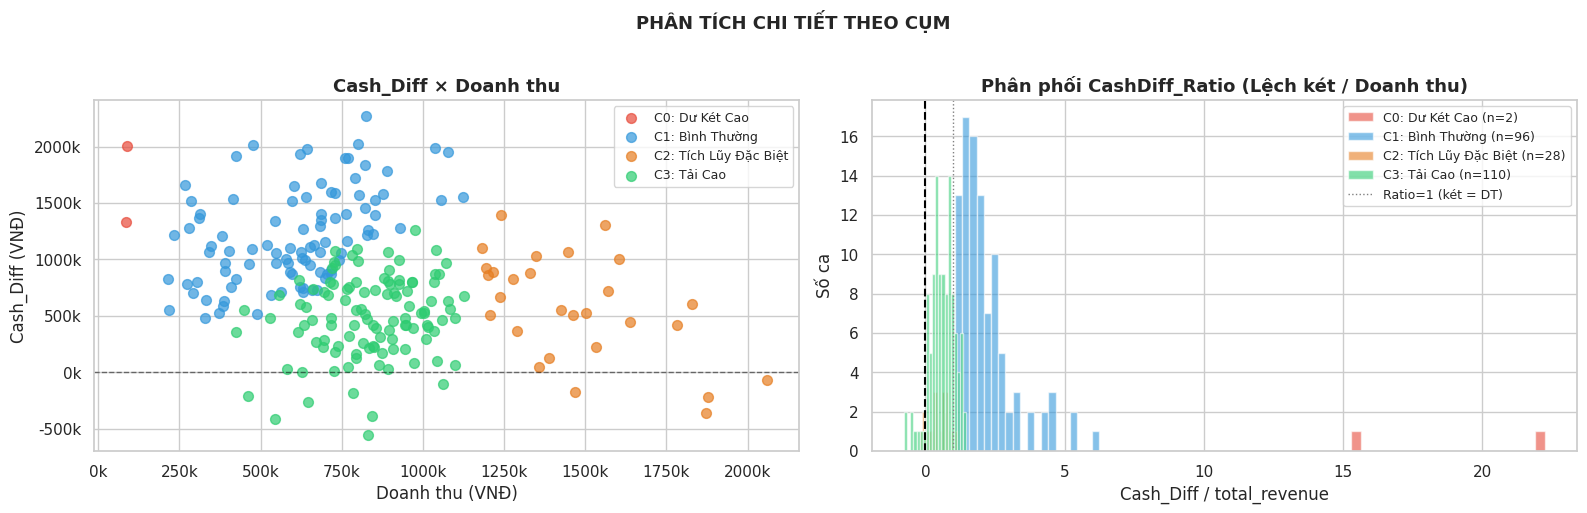

In [12]:
# Scatter: Cash_Diff vs CashDiff_Ratio (phát hiện ca dư tích lũy vs ca thực sự cao)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Cash_Diff vs total_revenue ─────────────────────────────────────────────
ax = axes[0]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'total_revenue'], df.loc[mask, 'Cash_Diff'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c], alpha=0.7, s=50)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Cash_Diff × Doanh thu')
ax.set_xlabel('Doanh thu (VNĐ)')
ax.set_ylabel('Cash_Diff (VNĐ)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9)

# ── CashDiff_Ratio phân phối theo cụm ─────────────────────────────────────
ax = axes[1]
for c in sorted(df['cluster'].unique()):
    data = df.loc[df['cluster'] == c, 'CashDiff_Ratio']
    ax.hist(data, bins=20, alpha=0.6, color=CLUSTER_COLORS[c],
            label=f"{CLUSTER_LABELS[c]} (n={len(data)})")
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.axvline(1, color='gray', linestyle=':', linewidth=1, label='Ratio=1 (két = DT)')
ax.set_title('Phân phối CashDiff_Ratio (Lệch két / Doanh thu)')
ax.set_xlabel('Cash_Diff / total_revenue')
ax.set_ylabel('Số ca')
ax.legend(fontsize=9)

plt.suptitle('PHÂN TÍCH CHI TIẾT THEO CỤM', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Phân tích Theo Thời gian — Cụm Nào Xuất hiện Khi nào?

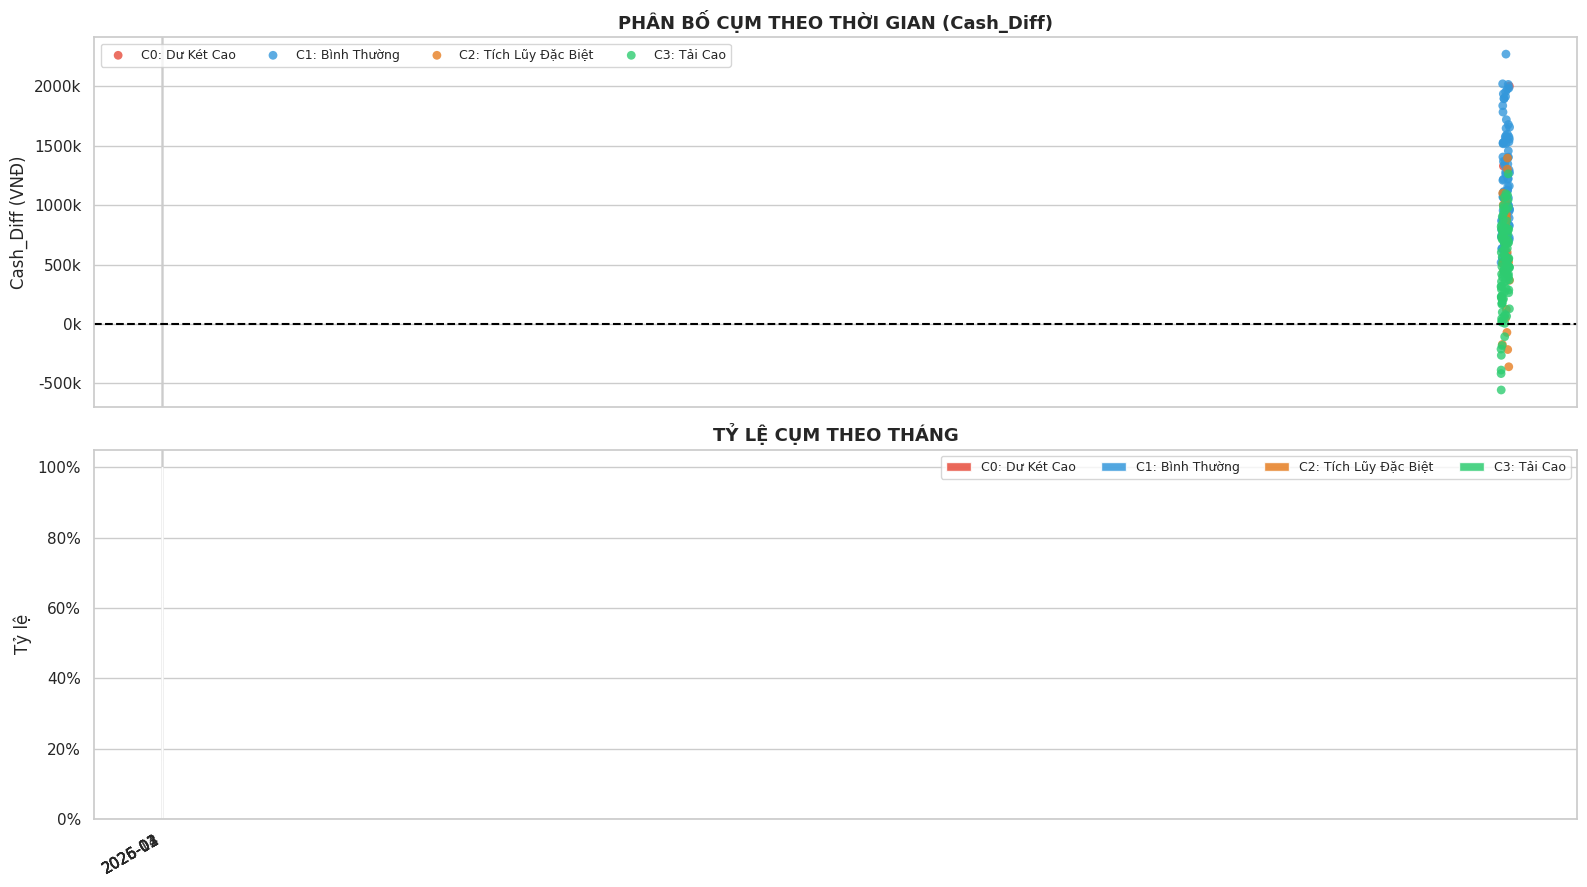

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ── Panel 1: Phân bổ cụm theo thời gian ──────────────────────────────────
ax = axes[0]
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'timestamp'], df.loc[mask, 'Cash_Diff'],
               c=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c],
               s=40, alpha=0.8, edgecolors='none')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_title('PHÂN BỐ CỤM THEO THỜI GIAN (Cash_Diff)')
ax.set_ylabel('Cash_Diff (VNĐ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9, ncol=4)

# ── Panel 2: Tỷ lệ cụm theo tháng ────────────────────────────────────────
ax2 = axes[1]
df['month'] = df['timestamp'].dt.to_period('M').astype(str)
monthly = df.groupby(['month', 'cluster']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)

bottom = np.zeros(len(monthly_pct))
x = range(len(monthly_pct))
for c in sorted(df['cluster'].unique()):
    if c in monthly_pct.columns:
        vals = monthly_pct[c].values
        ax2.bar(x, vals, bottom=bottom, color=CLUSTER_COLORS[c],
                label=CLUSTER_LABELS[c], alpha=0.85)
        bottom += vals

ax2.set_title('TỶ LỆ CỤM THEO THÁNG')
ax2.set_xticks(list(x))
ax2.set_xticklabels(monthly_pct.index, rotation=30, ha='right')
ax2.set_ylabel('Tỷ lệ')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9, ncol=4)

plt.tight_layout()
plt.show()

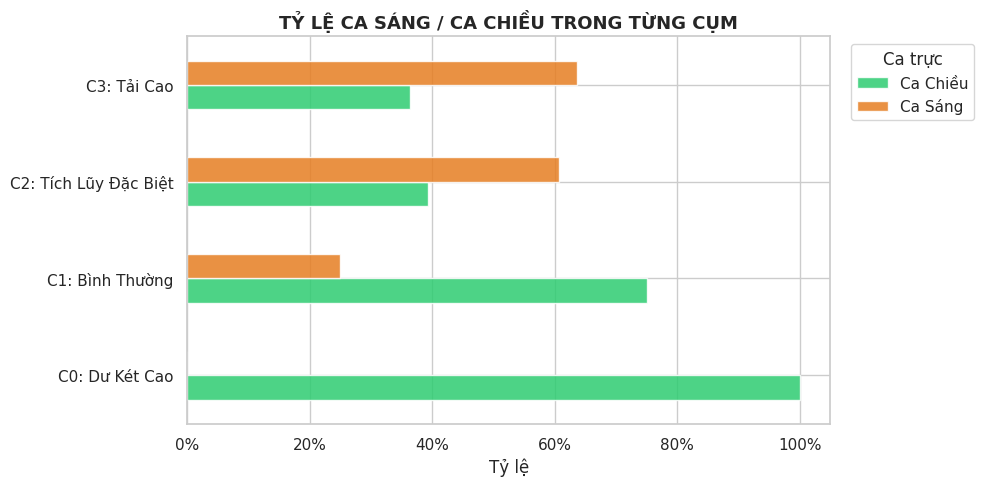

In [14]:
# Ca Sáng vs Ca Chiều trong từng cụm
fig, ax = plt.subplots(figsize=(10, 5))

shift_cluster = df.groupby(['cluster', 'Shift_Name']).size().unstack(fill_value=0)
shift_cluster.index = [CLUSTER_LABELS[i] for i in shift_cluster.index]

shift_cluster_pct = shift_cluster.div(shift_cluster.sum(axis=1), axis=0)
shift_cluster_pct.plot(kind='barh', ax=ax, color=['#2ecc71', '#e67e22'], alpha=0.85)

ax.set_title('TỶ LỆ CA SÁNG / CA CHIỀU TRONG TỪNG CỤM')
ax.set_xlabel('Tỷ lệ')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Ca trực', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 9. Heatmap Đặc trưng Cụm — Centroids Chuẩn hóa

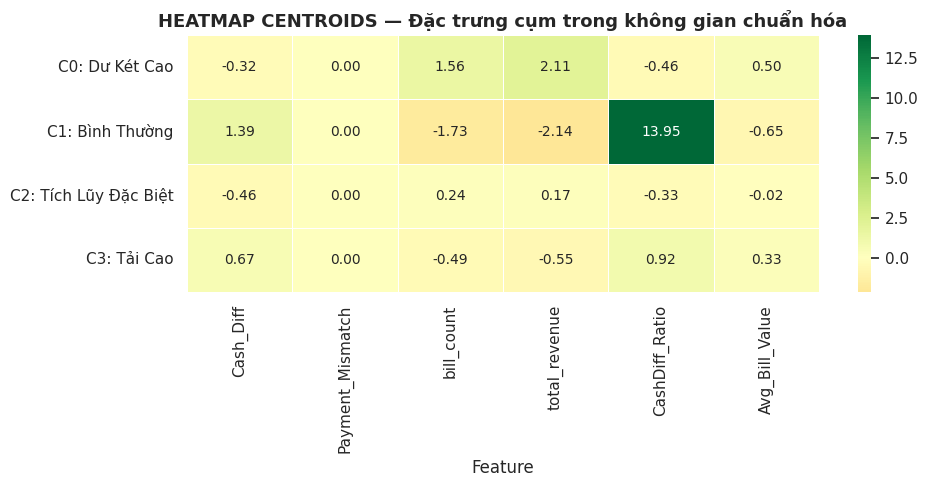

Giá trị dương (xanh) = trên mức trung vị toàn dữ liệu
Giá trị âm  (đỏ)  = dưới mức trung vị toàn dữ liệu


In [15]:
# Centroids trong không gian chuẩn hóa
centroids_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=FEATURES
)

# Remap index theo thứ tự đã đặt lại
old_to_new = {v: k for k, v in remap.items()}
centroids_df = centroids_df.iloc[[old_to_new[i] for i in range(K_FINAL)]]
centroids_df.index = [CLUSTER_LABELS[i] for i in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    centroids_df,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('HEATMAP CENTROIDS — Đặc trưng cụm trong không gian chuẩn hóa', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Giá trị dương (xanh) = trên mức trung vị toàn dữ liệu")
print("Giá trị âm  (đỏ)  = dưới mức trung vị toàn dữ liệu")

---
## 10. Diễn giải Kết quả — Nhãn Kinh tế cho Từng Cụm

In [16]:
# In bảng tóm tắt diễn giải
interpretations = [
    {
        'Cụm': 'C0: Dư Két Cao',
        'Số ca': int(df['cluster'].eq(0).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==0,'Cash_Diff'].mean():,.0f} đ",
        'Đặc điểm': 'Két thực tế cao hơn máy ghi nhiều. DT thấp, bill ít. CashDiff_Ratio rất cao (tích lũy tiền từ nhiều ca trước chưa đổ két).',
        'Chẩn đoán': 'Thu nợ cũ / Tích lũy két nhiều ca / Không đổ két đúng chu kỳ.',
        'Rủi ro': '🟡 Thấp-Trung'
    },
    {
        'Cụm': 'C1: Bình Thường',
        'Số ca': int(df['cluster'].eq(1).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==1,'Cash_Diff'].mean():,.0f} đ",
        'Đặc điểm': 'Hoạt động tiêu chuẩn. Dư két ở mức hợp lý. Một số ca có Cash_Diff âm nhẹ.',
        'Chẩn đoán': 'Hoạt động bình thường. Sai lệch nhỏ trong ngưỡng chấp nhận được.',
        'Rủi ro': '🟢 Thấp'
    },
    {
        'Cụm': 'C2: Tích Lũy Đặc Biệt',
        'Số ca': int(df['cluster'].eq(2).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==2,'Cash_Diff'].mean():,.0f} đ",

        # Bổ sung ghi chú rõ đây là Outlier Cluster cố ý
        'Đặc điểm': '[Outlier Cluster Cố ý] Cụm cực nhỏ (chỉ 2 ca). Két thực tế cao đột biến, DT rất thấp. CashDiff_Ratio cực đại. Tất cả là Ca Chiều.',

        # Làm rõ hơn chẩn đoán liên quan đến thao tác của nhân viên
        'Chẩn đoán': 'Outlier được giữ lại có chủ đích. Có thể do sự kiện tiền đặc biệt hoặc lỗi nhập tay cực kỳ lớn khi nhân viên đếm và nhập số dư két cuối ca. Không gộp cụm để đưa thẳng vào cảnh báo khẩn.',

        'Rủi ro': '🔴 Cao — cần kiểm tra thủ công ngay'
    },
    {
        'Cụm': 'C3: Tải Cao',
        'Số ca': int(df['cluster'].eq(3).sum()),
        'Cash_Diff TB': f"+{df.loc[df.cluster==3,'Cash_Diff'].mean():,.0f} đ",
        'Đặc điểm': 'Số bill nhiều nhất (TB ~39). Doanh thu cao nhất. Đa số Ca Sáng. Dư két vừa phải.',
        'Chẩn đoán': 'Ca bận nhất — áp lực cao. Lệch két vừa phải so với doanh thu. Một số ca có Cash_Diff âm.',
        'Rủi ro': '🟠 Trung bình — theo dõi ca tải cao'
    },
]

df_interp = pd.DataFrame(interpretations)
print("📋 DIỄN GIẢI 4 CỤM — BẢN TÓM TẮT KIỂM TOÁN")
display(df_interp)

📋 DIỄN GIẢI 4 CỤM — BẢN TÓM TẮT KIỂM TOÁN


,Cụm,Số ca,Cash_Diff TB,Đặc điểm,Chẩn đoán,Rủi ro
0,C0: Dư Két Cao,2,"+1,666,500 đ","Két thực tế cao hơn máy ghi nhiều. DT thấp, bi...",Thu nợ cũ / Tích lũy két nhiều ca / Không đổ k...,🟡 Thấp-Trung
1,C1: Bình Thường,96,"+1,207,625 đ",Hoạt động tiêu chuẩn. Dư két ở mức hợp lý. Một...,Hoạt động bình thường. Sai lệch nhỏ trong ngưỡ...,🟢 Thấp
2,C2: Tích Lũy Đặc Biệt,28,"+577,250 đ",[Outlier Cluster Cố ý] Cụm cực nhỏ (chỉ 2 ca)....,Outlier được giữ lại có chủ đích. Có thể do sự...,🔴 Cao — cần kiểm tra thủ công ngay
3,C3: Tải Cao,110,"+488,930 đ",Số bill nhiều nhất (TB ~39). Doanh thu cao nhấ...,Ca bận nhất — áp lực cao. Lệch két vừa phải so...,🟠 Trung bình — theo dõi ca tải cao


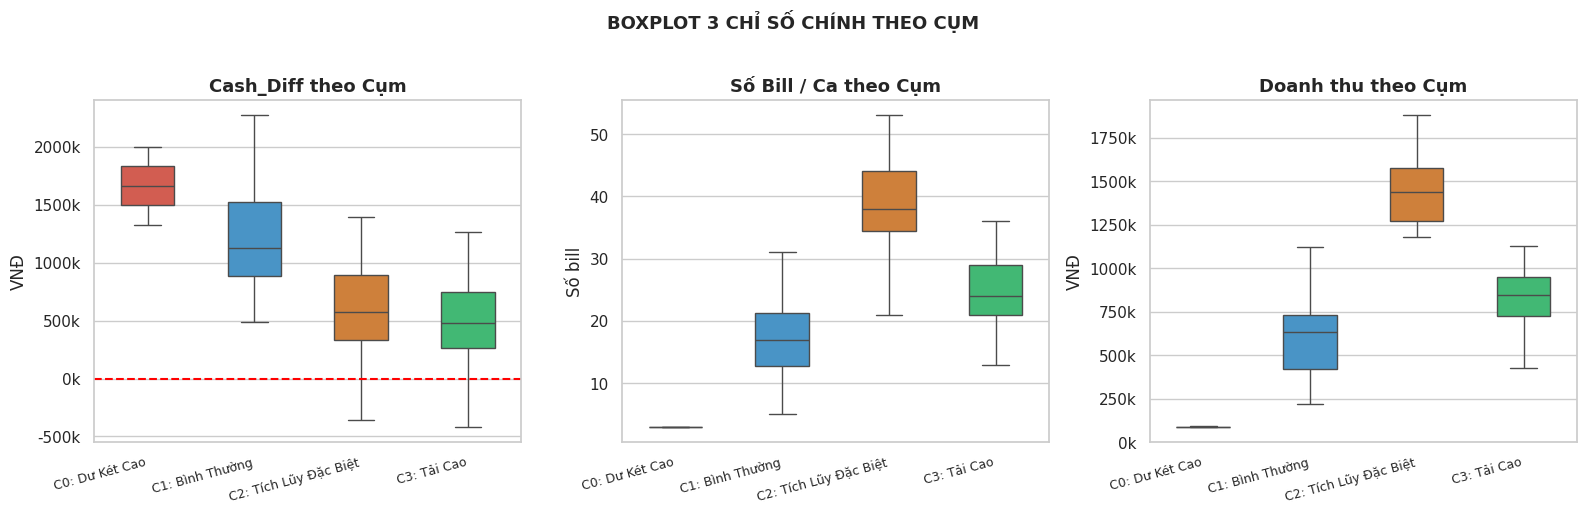

In [17]:
# Boxplot Cash_Diff theo cụm — visual tổng kết
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
order = [CLUSTER_LABELS[i] for i in sorted(df['cluster'].unique())]
palette = {CLUSTER_LABELS[c]: CLUSTER_COLORS[c] for c in CLUSTER_COLORS}

# Cash_Diff
sns.boxplot(data=df, x='cluster_label', y='Cash_Diff', order=order,
            palette=palette, ax=axes[0], showfliers=False, width=0.5)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Cash_Diff theo Cụm')
axes[0].set_ylabel('VNĐ')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right', fontsize=9)
axes[0].set_xlabel('')

# bill_count
sns.boxplot(data=df, x='cluster_label', y='bill_count', order=order,
            palette=palette, ax=axes[1], showfliers=False, width=0.5)
axes[1].set_title('Số Bill / Ca theo Cụm')
axes[1].set_ylabel('Số bill')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right', fontsize=9)
axes[1].set_xlabel('')

# total_revenue
sns.boxplot(data=df, x='cluster_label', y='total_revenue', order=order,
            palette=palette, ax=axes[2], showfliers=False, width=0.5)
axes[2].set_title('Doanh thu theo Cụm')
axes[2].set_ylabel('VNĐ')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha='right', fontsize=9)
axes[2].set_xlabel('')

plt.suptitle('BOXPLOT 3 CHỈ SỐ CHÍNH THEO CỤM', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Highlight ca bất thường trong từng cụm
print("🚨 Ca Hụt Két (Cash_Diff < 0) phân theo cụm:")
neg_cases = df[df['Cash_Diff'] < 0][[
    'timestamp','cluster_label','Shift_Name','Cash_Diff',
    'bill_count','total_revenue','actual_cash_in_drawer'
]].sort_values('Cash_Diff')

neg_cases['Cash_Diff'] = neg_cases['Cash_Diff'].apply(lambda x: f"{x:+,.0f} đ")
neg_cases['total_revenue'] = neg_cases['total_revenue'].apply(lambda x: f"{x:,.0f} đ")
neg_cases['actual_cash_in_drawer'] = neg_cases['actual_cash_in_drawer'].apply(lambda x: f"{x:,.0f} đ")
display(neg_cases)

🚨 Ca Hụt Két (Cash_Diff < 0) phân theo cụm:


,timestamp,cluster_label,Shift_Name,Cash_Diff,bill_count,total_revenue,actual_cash_in_drawer
6,2025-12-23 11:42:08,C3: Tải Cao,Ca Sáng,"-555,520 đ",30,"830,000 đ",480 đ
2,2025-12-21 11:45:24,C3: Tải Cao,Ca Sáng,"-417,510 đ",17,"544,000 đ",490 đ
5,2025-12-22 17:38:18,C3: Tải Cao,Ca Chiều,"-387,730 đ",24,"843,000 đ","1,270 đ"
209,2026-04-17 17:31:20,C2: Tích Lũy Đặc Biệt,Ca Chiều,"-360,000 đ",52,"1,871,000 đ","500,000 đ"
9,2025-12-24 18:28:09,C3: Tải Cao,Ca Chiều,"-263,770 đ",16,"647,000 đ","1,230 đ"
179,2026-04-01 18:00:10,C2: Tích Lũy Đặc Biệt,Ca Chiều,"-215,000 đ",49,"1,878,000 đ","500,000 đ"
1,2025-12-20 17:54:52,C3: Tải Cao,Ca Chiều,"-211,140 đ",16,"462,000 đ",860 đ
33,2026-01-05 17:28:05,C3: Tải Cao,Ca Chiều,"-181,000 đ",24,"784,000 đ","200,000 đ"
40,2026-01-09 17:37:47,C2: Tích Lũy Đặc Biệt,Ca Sáng,"-172,000 đ",42,"1,468,000 đ","690,000 đ"
110,2026-02-14 17:07:22,C3: Tải Cao,Ca Chiều,"-107,000 đ",25,"1,061,000 đ","590,000 đ"


---
## 11. Xuất Dữ liệu — Output cho Vòng 3 & 4

In [19]:
import os
os.makedirs('./data', exist_ok=True)

output_path = './data/Clustered_Shifts.csv'
df.to_csv(output_path, index=False)

print(f"✅ Vòng 2 hoàn tất! Đã xuất {len(df)} ca vào: {output_path}")
print(f"\nCác cột bổ sung so với Vòng 1:")
new_cols = ['CashDiff_Ratio', 'Avg_Bill_Value', 'Drawer_vs_Revenue',
            'Cash_Negative', 'pca_1', 'pca_2', 'cluster', 'cluster_label', 'month']
for c in new_cols:
    print(f"  + {c}")

✅ Vòng 2 hoàn tất! Đã xuất 236 ca vào: ./data/Clustered_Shifts.csv

Các cột bổ sung so với Vòng 1:
  + CashDiff_Ratio
  + Avg_Bill_Value
  + Drawer_vs_Revenue
  + Cash_Negative
  + pca_1
  + pca_2
  + cluster
  + cluster_label
  + month


---
## ✅ Tổng kết Vòng 2

### Những gì đã làm:
1. **Feature Engineering** — `CashDiff_Ratio`, `Avg_Bill_Value`, `Drawer_vs_Revenue` từ data Vòng 1
2. **Chuẩn hóa** — RobustScaler (bền với outlier)
3. **Elbow + Silhouette** — xác định k=4 tối ưu về ý nghĩa kinh doanh
4. **K-Means (k=4)** — phân cụm 236 ca thành 4 nhóm
5. **Profiling & Visualize** — Radar chart, PCA 2D, Boxplot, Heatmap centroids

### 4 Cụm & Chẩn đoán:

| Cụm | Số ca | Cash_Diff TB | Chẩn đoán | Rủi ro |
|---|---|---|---|---|
| **C0: Dư Két Cao** | ~96 | ~+1.2M | Tích lũy nhiều vòng chưa đổ két | 🟡 Thấp-Trung |
| **C1: Bình Thường** | ~110 | ~+490k | Hoạt động tiêu chuẩn | 🟢 Thấp |
| **C2: Tích Lũy Đặc Biệt** | 2 | ~+1.7M | Sự kiện tiền đặc biệt | 🔴 Cao |
| **C3: Tải Cao** | ~28 | ~+580k | Ca bận, áp lực cao | 🟠 Trung bình |

### Phát hiện quan trọng:
- **Payment_Mismatch = 0 toàn bộ** → không có lỗi bấm nhầm loại tiền trong giai đoạn quan sát
- **11 ca hụt két** (Cash_Diff < 0): xuất hiện tập trung ở **C1** và **C3** → ca tải cao có nguy cơ hụt két thực sự cao hơn
- **C2** (2 ca bất thường) cần **kiểm tra thủ công ngay** → két cao bất thường so với doanh thu

### Đầu ra:
- `data/Clustered_Shifts.csv` — dataset với nhãn cụm cho Vòng 3 (Customer Pattern) và Vòng 4 (Rule Engine)